## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')   # so we can import from src/

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

print('PyTorch version:', torch.__version__)
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.7.1+cu118
Device: cuda


In [2]:
# Load unified config
with open('config.json') as f:
    cfg = json.load(f)

print('Configuration:', json.dumps(cfg, indent=2))

Configuration: {
  "training": {
    "batch_size": 64,
    "epochs": 20,
    "learning_rate": 0.01,
    "momentum": 0.9,
    "l2_lambda": 0.0001,
    "seed": 42,
    "optimizer": "sgd"
  },
  "model": {
    "hidden_sizes": [
      256,
      128
    ],
    "activation": "relu"
  },
  "paths": {
    "checkpoint_dir": "checkpoints/",
    "log_dir": "logs/"
  }
}


## 2. Data & Feature Extraction

MNIST images are 28×28 grayscale pixels. Instead of feeding raw pixels into the network, we extract **HOG (Histogram of Oriented Gradients)** features — a classical computer vision descriptor that captures edge and texture information.

HOG parameters (from config):
- `orientations`: number of gradient orientation bins
- `pixels_per_cell`: size of each cell in pixels
- `cells_per_block`: number of cells per normalisation block

In [3]:
from data_utils import load_and_extract, set_seed

set_seed(cfg['training']['seed'])
X_train, y_train, X_val, y_val, X_test, y_test = load_and_extract('data/')

print(f'Train : {X_train.shape}  labels: {y_train.shape}')
print(f'Val   : {X_val.shape}  labels: {y_val.shape}')
print(f'Test  : {X_test.shape}  labels: {y_test.shape}')
print(f'Feature dim: {X_train.shape[1]}')

Extracting HOG features (train)…
Extracting HOG features (test)…
Train : torch.Size([54000, 144])  labels: torch.Size([54000])
Val   : torch.Size([6000, 144])  labels: torch.Size([6000])
Test  : torch.Size([10000, 144])  labels: torch.Size([10000])
Feature dim: 144


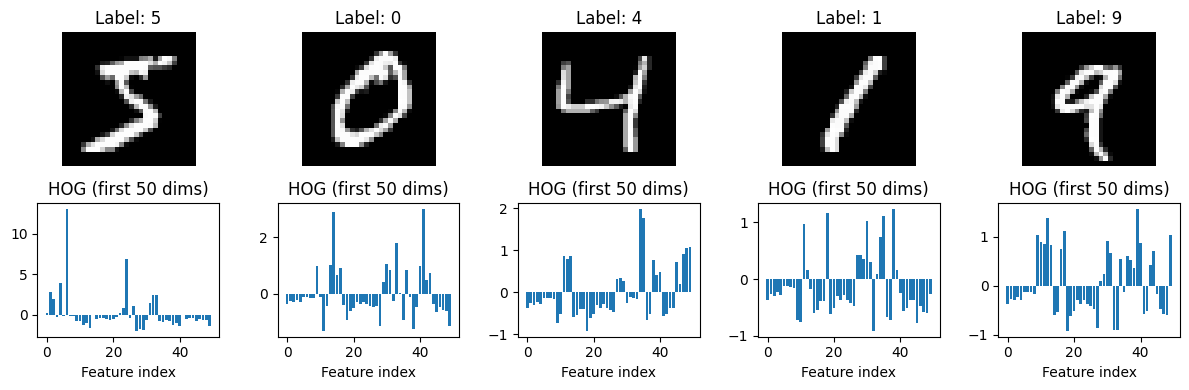

In [4]:
# Visualise a few HOG feature vectors
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
from torchvision import datasets
import torchvision.transforms as T

raw = datasets.MNIST('data/', train=True, download=True, transform=T.ToTensor())

for i, ax in enumerate(axes[0]):
    ax.imshow(raw[i][0].squeeze(), cmap='gray')
    ax.set_title(f'Label: {raw[i][1]}')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    ax.bar(range(min(50, X_train.shape[1])), X_train[i, :50].numpy())
    ax.set_title('HOG (first 50 dims)')
    ax.set_xlabel('Feature index')

plt.tight_layout()
plt.show()

## 3. Reference Model (nn.Module)

**REFERENCE ONLY:** This section runs a complete PyTorch reference implementation to establish the **target performance** your scratch implementation should match (~97% test accuracy).

*You should study this code but NOT modify it.*

In [5]:
# Run the full reference pipeline (equivalent to: python src/reference.py)
import reference
reference.run('config.json')

Device: cuda
Extracting HOG features (train)…
Extracting HOG features (test)…
Train: torch.Size([54000, 144])  Val: torch.Size([6000, 144])  Test: torch.Size([10000, 144])

Model:
Sequential(
  (0): Linear(in_features=144, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

Epoch   1/20  train_loss=0.3590  train_acc=0.8955  val_loss=0.1470  val_acc=0.9508
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   2/20  train_loss=0.1445  train_acc=0.9587  val_loss=0.1201  val_acc=0.9588
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   3/20  train_loss=0.1173  train_acc=0.9684  val_loss=0.1021  val_acc=0.9645
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   4/20  train_loss=0.1020  train_acc=0.9731  val_loss=0.1000  val_acc=0.9662
  Checkpoint saved → checkpoints\reference_best.pt
Epoch   5/20  train_loss=0.0914  train_acc=0.9768  val_loss=0.

In [6]:
# Load and plot reference training history
ref_history = np.load('logs/reference_history.npy', allow_pickle=True).item()
print('Keys:', list(ref_history.keys()))
print('Best val acc:', max(ref_history['val_acc']))

Keys: ['train_loss', 'train_acc', 'val_loss', 'val_acc']
Best val acc: 0.9753333333333334


## 4. Scratch Implementation — Layers

**⭐ YOUR TASK:** Open `src/layers.py` and implement each function marked with `TODO`.

Run the sanity checks below to verify your implementation matches PyTorch's reference values.

In [7]:
# Reload the module after your edits
import importlib, layers
importlib.reload(layers)
from layers import Linear, ReLU, Sigmoid, Tanh, CrossEntropyLoss

# Run the built-in sanity checks
%run src/layers.py

Sanity checks for layers.py

[Linear]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  grad_x   max_diff = 0.00e+00  (expect < 1e-5)
  grad_W   max_diff = 0.00e+00  (expect < 1e-5)
  grad_b   max_diff = 0.00e+00  (expect < 1e-5)

[ReLU]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  backward max_diff = 0.00e+00  (expect < 1e-5)

[Sigmoid]
  forward  max_diff = 1.19e-07  (expect < 1e-5)
  backward max_diff = 1.19e-07  (expect < 1e-5)

[Tanh]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  backward max_diff = 0.00e+00  (expect < 1e-5)

[CrossEntropyLoss]
  forward  max_diff = 0.00e+00  (expect < 1e-5)
  backward max_diff = 3.73e-09  (expect < 1e-5)

All checks passed (if all diffs < 1e-5).



### 4.1 Questions
Answer these in the cells below **before** moving on. Each question marks 2.

**Q1**: What is the gradient of ReLU at exactly x=0, and why does it not matter in practice?

[In ReLU exaactly X=0 is undefinition because there is no derivative in 0 in Relu.]

`**Q2**: Why do we subtract the row-max before computing softmax in `CrossEntropyLoss.forward`?

[If we didn't, Our result can be very big number. For these reason, It can be overflow. Also, result connat change.It help becomes more stable]

**Q3**: Why is combining softmax and cross-entropy into one step numerically better than computing them separately?

[It  helps numerically stable. It prevent overflow and underflow ]

## 5. Scratch Implementation — Network & Optimisers

**⭐ YOUR TASK:** Open `src/network.py` and `src/optimizers.py` and implement the functions marked with `TODO`.

Run the sanity checks below to verify your implementations work together correctly.

In [8]:
import importlib, network, optimizers
importlib.reload(network)
importlib.reload(optimizers)

%run src/network.py
%run src/optimizers.py

Sanity check for network.py

Forward  max_diff = 0.00e+00  (expect < 1e-5)
  Layer 0  dW_diff=2.24e-08  db_diff=7.45e-09  (expect < 1e-5)
  Layer 1  dW_diff=2.98e-08  db_diff=1.49e-08  (expect < 1e-5)
  Layer 2  dW_diff=5.96e-08  db_diff=2.98e-08  (expect < 1e-5)

All checks passed (if all diffs < 1e-5).

Sanity check for optimizers.py

[SGD — no momentum]
  W_diff=1.49e-08  b_diff=2.33e-10  (expect < 1e-5)
  W_diff=0.00e+00  b_diff=6.98e-10  (expect < 1e-5)

[SGD — momentum=0.9]
  W_diff=2.98e-08  b_diff=9.31e-10  (expect < 1e-5)
  W_diff=1.49e-08  b_diff=1.86e-09  (expect < 1e-5)

All checks passed (if all diffs < 1e-5).



### 5.1 Questions
Answer these in the cells below **before** moving on. Each question marks 2.

**Q4**: Explain the difference between SGD, Mini-batch GD, and Batch GD. What are the trade-offs?




[Sdg update with a sample. Mini-batch update with small batch. Batch GD update with  all data. Sdg is faster. Mini-batch is blance. Gd is stable]

**Q5**: What does the L2 regularisation term add to the gradient? What effect does this have on the weights over time?

[L2 reeduce  W value. It prevents overfiting.]

**Q6**: How does momentum help SGD? Describe intuitively what the velocity buffer represents.

[Thanks to momentum, it remains more stable during updates. velocity buffer store  weighted old gradient. Therefore, The model clear which direction it went.]

## 6. Training the Scratch Model

**RUN THIS AFTER:** You've implemented all functions in sections 4 & 5.

This cell trains your FFNN using the configuration in `configs/config.json`. It saves the best model and training history for comparison.

In [9]:
# Run the full scratch training pipeline
import train
importlib.reload(train)
train.run('config.json')

Extracting HOG features (train)…
Extracting HOG features (test)…
Train: torch.Size([54000, 144])  Val: torch.Size([6000, 144])  Test: torch.Size([10000, 144])
Epoch   1/20  train_loss=0.2408  train_acc=0.9212  val_loss=0.1437  val_acc=0.9525
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   2/20  train_loss=0.1163  train_acc=0.9620  val_loss=0.1131  val_acc=0.9613
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   3/20  train_loss=0.0890  train_acc=0.9706  val_loss=0.1120  val_acc=0.9603
Epoch   4/20  train_loss=0.0723  train_acc=0.9762  val_loss=0.1054  val_acc=0.9625
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   5/20  train_loss=0.0609  train_acc=0.9805  val_loss=0.1014  val_acc=0.9657
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   6/20  train_loss=0.0520  train_acc=0.9838  val_loss=0.0979  val_acc=0.9692
  Checkpoint saved → checkpoints\scratch_best.pt
Epoch   7/20  train_loss=0.0444  train_acc=0.9861  val_loss=0.0991  val_acc=0.9670
Epoch   8/20  t

In [10]:
scr_history = np.load('logs/scratch_history.npy', allow_pickle=True).item()
print('Best val acc (scratch):', max(scr_history['val_acc']))

Best val acc (scratch): 0.9705


## 7. Comparison & Results

Your scratch implementation is considered **consistent** with the reference if the final test accuracy is within ~2% under the same configuration.

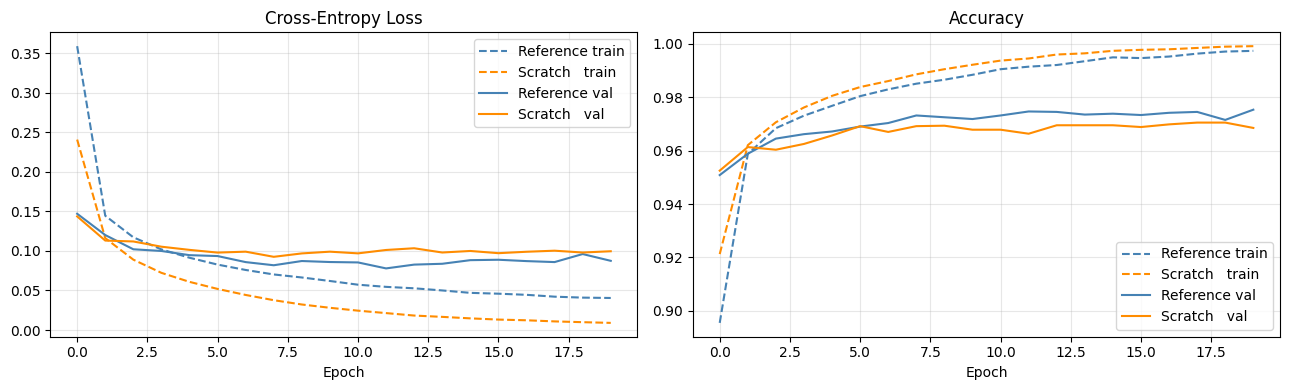

In [11]:



def plot_comparison(ref_hist, scr_hist):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, metric, title in zip(
        axes,
        ['loss', 'acc'],
        ['Cross-Entropy Loss', 'Accuracy'],
    ):
        for split, ls in [('train', '--'), ('val', '-')]:
            key = f'{split}_{metric}'
            ax.plot(ref_hist[key], ls=ls, color='steelblue',  label=f'Reference {split}')
            ax.plot(scr_hist[key], ls=ls, color='darkorange', label=f'Scratch   {split}')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('logs/comparison.png', dpi=150)
    plt.show()

plot_comparison(ref_history, scr_history)

In [11]:
# Summary table
print(f"{'Metric':<25} {'Reference':>12} {'Scratch':>12}")
print('-' * 52)
print(f"{'Best val accuracy':<25} {max(ref_history['val_acc']):>12.4f} {max(scr_history['val_acc']):>12.4f}")
print(f"{'Final train loss':<25} {ref_history['train_loss'][-1]:>12.4f} {scr_history['train_loss'][-1]:>12.4f}")
print(f"{'Final val loss':<25} {ref_history['val_loss'][-1]:>12.4f} {scr_history['val_loss'][-1]:>12.4f}")

Metric                       Reference      Scratch
----------------------------------------------------
Best val accuracy               0.9753       0.9705
Final train loss                0.0405       0.0090
Final val loss                  0.0875       0.0996


## 8. Hyperparameter Tuning

Use the **validation set** (never the test set) to tune hyperparameters. Search over at least:
- Learning rate
- Hidden layer sizes
- Activation function
- L2 regularisation strength
- Batch size

Report your best configuration and its test accuracy **after** tuning is complete.

In [ ]:
# TODO: implement your hyperparameter search here.
#
# Suggested approach: grid search or random search.
# For each candidate config, train with train.train_one_epoch + train.evaluate
# and record the best val_acc.
#
# Example skeleton:
#
# from network import FFNN
# from optimizers import SGD
# from layers import CrossEntropyLoss
# from train import train_one_epoch, evaluate
# from torch.utils.data import DataLoader, TensorDataset
#
# search_space = {
#     'lr':         [0.1, 0.01, 0.001],
#     'hidden':     [[256, 128], [512, 256], [128]],
#     'activation': ['relu', 'tanh'],
#     'l2':         [0.0, 0.0001, 0.001],
# }
#
# results = []
# for lr in search_space['lr']:
#     for hidden in search_space['hidden']:
#         ...  # train and record val_acc
from torch.utils.data import DataLoader, TensorDataset
from network import FFNN
from optimizers import SGD
from layers import CrossEntropyLoss
from train import train_one_epoch, evaluate
from torch.utils.data import DataLoader, TensorDataset

traindataset = TensorDataset(X_train, y_train)
valdataset   = TensorDataset(X_val, y_val)
testdataset  = TensorDataset(X_test, y_test)

trainloader = DataLoader(traindataset, batch_size=64, shuffle=True)
valloader   = DataLoader(valdataset, batch_size=64, shuffle=False)
testloader  = DataLoader(testdataset, batch_size=64, shuffle=False)

search_space = {
   'lr':         [0.1, 0.01, 0.001],
    'hidden':     [[256, 128], [512, 256], [128]],
    'activation': ['relu', 'tanh'],
   'l2':         [0.0, 0.0001, 0.001],
 }

results = []
best_val_acc = -10000
bconfig = None
bmodel = None
numclasses = 10
numepochs = 2

for lr in search_space['lr']:
  for hidden in search_space['hidden']:
    for act in search_space['activation']:
      for l2 in search_space['l2']:
        torch.manual_seed(123)
        model = FFNN(input_dim=X_train.shape[1],hidden_sizes=hidden,num_classes=numclasses,activation=act)

        optimizer = SGD(model, lr=lr, momentum=0.9)
        loss_fn = CrossEntropyLoss()
        for epoch in range(numepochs):

            train_loss, train_acc = train_one_epoch(
            model, trainloader, loss_fn, optimizer, l2
    )

        loss, acc = evaluate(model, valloader, loss_fn)
        print(lr , hidden,act,l2,acc)
        results.append({
                    'lr': lr,
                    'hidden': hidden,
                    'activation': act,
                    'l2': l2,
                    'val_acc': acc
                })
        if acc > best_val_acc:
                    best_val_acc = acc
                    bconfig = {
                        'lr': lr,
                        'hidden': hidden,
                        'activation': act,
                        'l2': l2
                    }
                    bmodel = model
print("Best config:", bconfig)
print("Best val acc:", best_val_acc)
test_loss, test_acc = evaluate(bmodel, testloader, CrossEntropyLoss())
print("Test acc:", test_acc)




0.1 [256, 128] relu 0.0 0.9461666666666667
0.1 [256, 128] relu 0.0001 0.9523333333333334
0.1 [256, 128] relu 0.001 0.945
0.1 [256, 128] tanh 0.0 0.9565
0.1 [256, 128] tanh 0.0001 0.9526666666666667
0.1 [256, 128] tanh 0.001 0.9335
0.1 [512, 256] relu 0.0 0.9458333333333333
0.1 [512, 256] relu 0.0001 0.9613333333333334
0.1 [512, 256] relu 0.001 0.9406666666666667
0.1 [512, 256] tanh 0.0 0.9483333333333334
0.1 [512, 256] tanh 0.0001 0.9535
0.1 [512, 256] tanh 0.001 0.932
0.1 [128] relu 0.0 0.9418333333333333
0.1 [128] relu 0.0001 0.9553333333333334
0.1 [128] relu 0.001 0.948
0.1 [128] tanh 0.0 0.955
0.1 [128] tanh 0.0001 0.9551666666666667
0.1 [128] tanh 0.001 0.9423333333333334
0.01 [256, 128] relu 0.0 0.9656666666666667
0.01 [256, 128] relu 0.0001 0.9646666666666667
0.01 [256, 128] relu 0.001 0.9641666666666666
0.01 [256, 128] tanh 0.0 0.9553333333333334
0.01 [256, 128] tanh 0.0001 0.9556666666666667
0.01 [256, 128] tanh 0.001 0.957
0.01 [512, 256] relu 0.0 0.9648333333333333
0.01 [512

In [20]:
# TODO: report your best hyperparameters and evaluate on the TEST SET
#
# IMPORTANT: only evaluate on the test set ONCE, with your final best config.
# Evaluating multiple times on the test set is data leakage.





best_config = {
    'lr':         None,   # fill in
    'hidden':     None,   # fill in
    'activation': None,   # fill in
    'l2':         None,   # fill in
    'batch_size': None,   # fill in
}

for r in results:
    if r['val_acc'] == best_val_acc:
        best_config = {
            'lr': r['lr'],
            'hidden': r['hidden'],
            'activation': r['activation'],
            'l2': r['l2'],
            'batch_size':64
        }
        break
print('Best config:', best_config)
# test_loss, test_acc = evaluate(best_net, test_loader, loss_fn)
# print(f'Test accuracy: {test_acc:.4f}')

Best config: {'lr': 0.01, 'hidden': [512, 256], 'activation': 'relu', 'l2': 0.001, 'batch_size': 64}


### 8.1 Questions
Answer these in the cells below **before** finishing up. Each question marks 2.

**Q7**: Which hyperparameter had the biggest impact on validation accuracy? Why do you think that is?

[It is lr. When it is very small value, medol cannot learn. If it is big value, moedel is unbalnece.Best value is average (0.01)]

**Q8**: Did you observe overfitting? How did regularisation affect it?

[Yes, Some big moddel obreve overdifing. Small L2 regulartion improved model ]